# 1. Konfiguracja środowiska oraz datasetu

## 1.1. Instalacja zależności

In [ ]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
%pip install -r requirements.txt

## 1.2.Konfiguracja importów

In [1]:
import torch
import random
from pathlib import Path
from IPython.display import Audio
from src.process_guitarset import process_dataset
from src.config import *
from src.dataset import GuitarSetDataset, collate_fn
from torch.utils.data import DataLoader
from src.visualization import (
    plot_audio_waveform,
    plot_cqt,
    plot_annotation_map,
    create_annotation_maps
)

## 1.3. Konfiguracja GPU - automatyczne wykrywanie

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Używane urządzenie: {device}")
if device.type == 'cuda':
    print(f"Model karty GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True

Używane urządzenie: cpu


## 1.4. Wczytanie guitarsetu

In [4]:
config = {
    "data_dir": "src/guitarset_data",
    "output_dir": "src/processed_data",
    "seed": 42,
    "apply_augmentation": False,
    "max_tracks": None,
    "overwrite": False
}

process_dataset(**config)

100%|██████████| 360/360 [01:44<00:00,  3.45it/s]
INFO: Success: the dataset is complete and all files are valid.
INFO: --------------------
Processing test: 100%|██████████| 36/36 [06:00<00:00, 10.02s/it]


## 1.5. Wczytanie guitarseta z plików batch

In [8]:
# Wczytanie danych z plików
train_dir = Path(config["output_dir"]) / "train"
val_dir = Path(config["output_dir"]) / "val"
test_dir = Path(config["output_dir"]) / "test"

train_dataset = GuitarSetDataset(train_dir)
val_dataset = GuitarSetDataset(val_dir)
test_dataset = GuitarSetDataset(test_dir)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=4
)

## 1.6. Wizualizacja przykładowego pliku

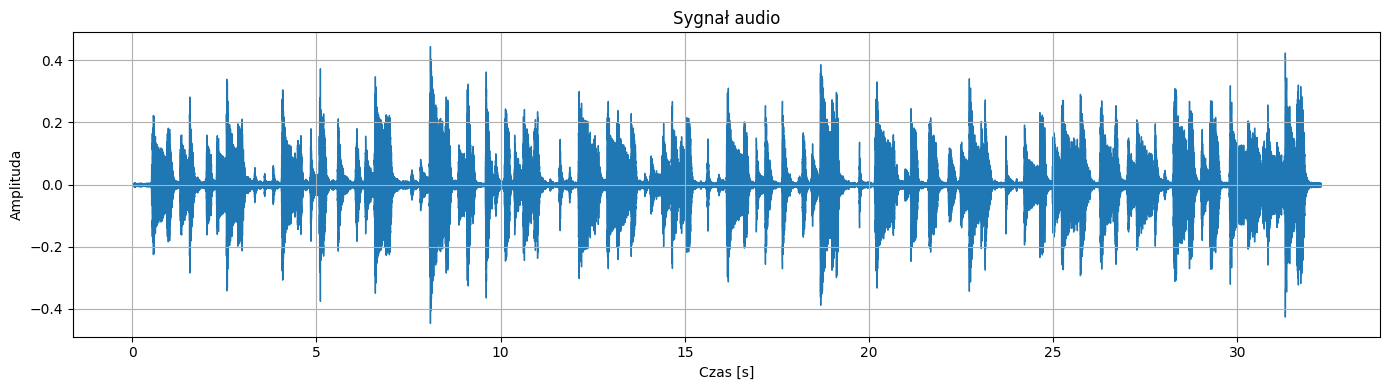

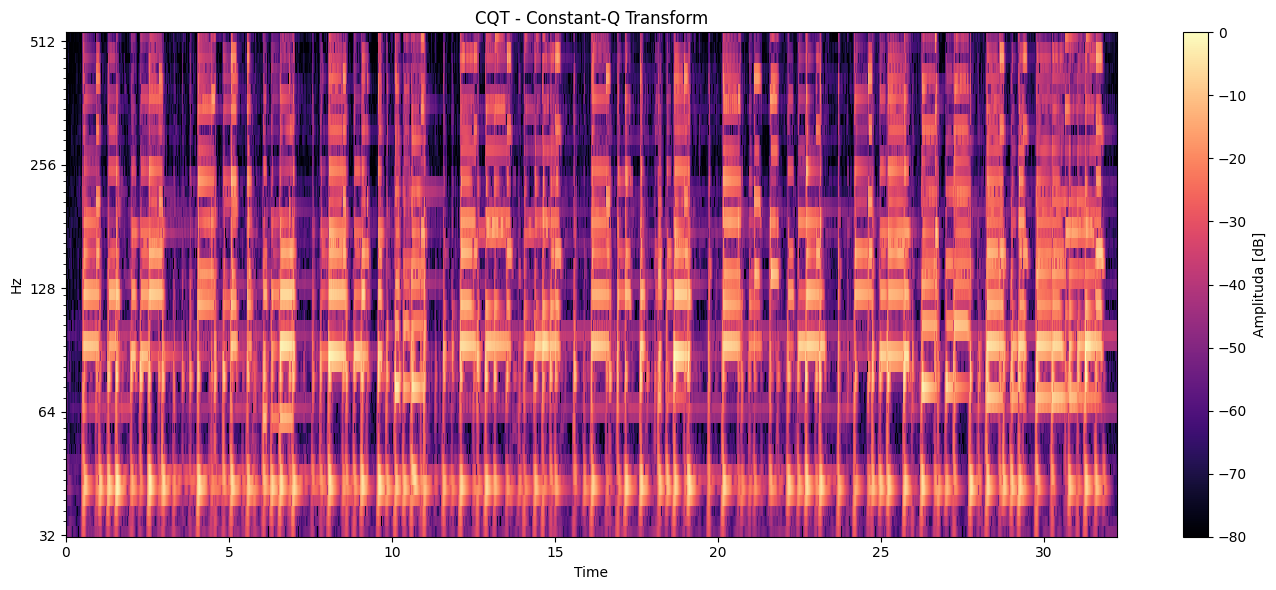

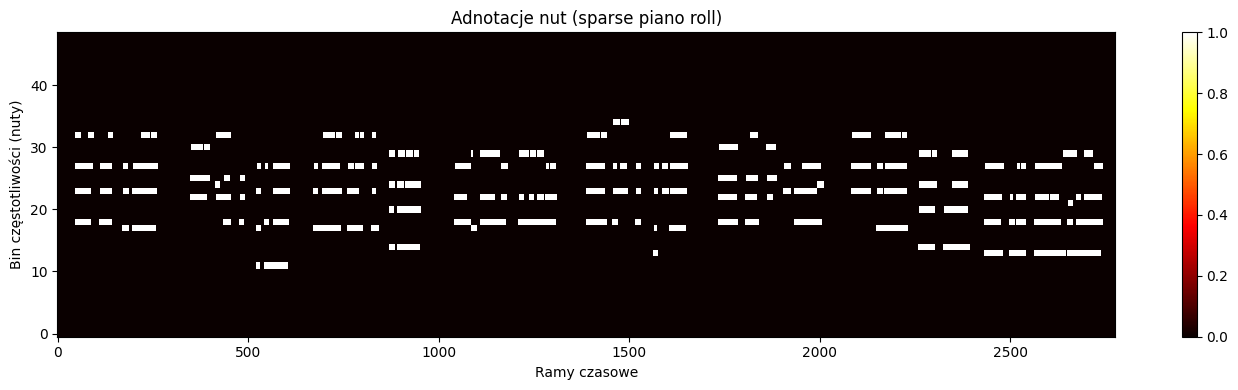

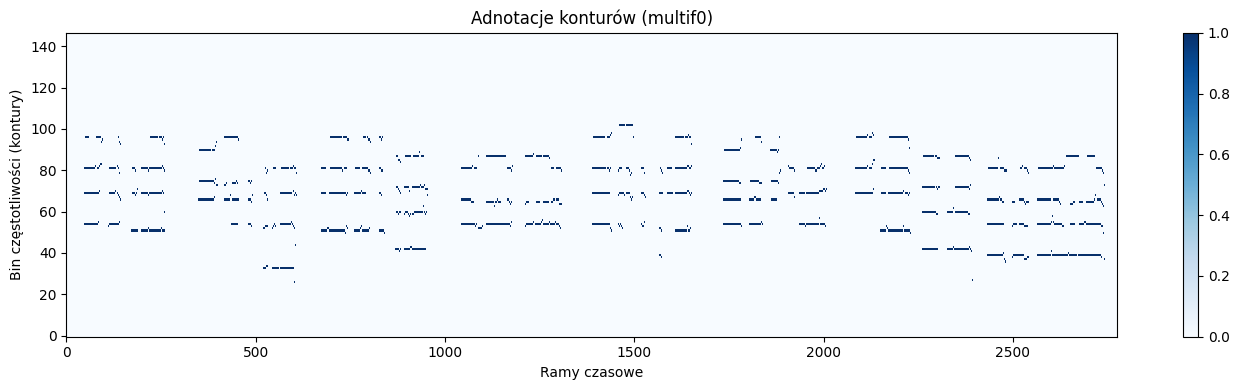

In [7]:
sample = random.choice(train_dataset)

# Dane surowe
audio = sample["audio"].numpy()
cqt = sample["features"].numpy()
sr = sample["sample_rate"]

# Wizualizacja audio i CQT
plot_audio_waveform(audio, sr)
plot_cqt(cqt, sr, hop_length=FFT_HOP, bins_per_octave=12 * NOTES_BINS_PER_SEMITONE)

# Wizualizacja adnotacji nut i konturów
notes_map, contours_map = create_annotation_maps(sample)
plot_annotation_map(notes_map, title="Adnotacje nut (sparse piano roll)", ylabel="Bin częstotliwości (nuty)",
                    cmap='hot')
plot_annotation_map(contours_map, title="Adnotacje konturów (multif0)", ylabel="Bin częstotliwości (kontury)",
                    cmap='Blues')
# Odtwarzanie audio
Audio(audio, rate=sr)
